1. **Monte um passo a passo para o algoritmo RF**
2. **Explique com suas palavras o Random Forest**
3. Qual a diferença entre Bagging e Random Forest ?
4. Implementar em python  Random Forest
    1. Bootstrap
    2. Modelagem
    3. Agregação

---

### **1**

### **Passo a Passo do Random Forest:**

1. **Preparação dos Dados**: A partir do conjunto de dados original, são gerados diversos subconjuntos por meio de amostragem com reposição (bootstrap). Diferente do bagging tradicional — que seleciona apenas linhas —, no Random Forest também é realizada uma seleção aleatória de colunas (features). Isso significa que cada árvore será treinada com uma amostra específica de observações *e* uma quantidade limitada de colunas, escolhidas aleatoriamente.
2. **Base Learners (Árvores de Decisão)**: Para cada subconjunto gerado, é treinada uma árvore de decisão (seja de classificação ou regressão). Essas árvores são chamadas de *base learners*. Como cada uma é alimentada com diferentes linhas e colunas, os modelos se tornam mais diversos, permitindo capturar diferentes padrões do problema — uma vantagem em relação ao bagging tradicional, que utiliza todas as colunas em cada modelo.
3. **Agregação**: Após o treinamento, as previsões de todas as árvores são combinadas para formar a previsão final do modelo. Em tarefas de **classificação**, a decisão final é feita por **votação da maioria**. Já em tarefas de **regressão**, calcula-se a **média** das previsões. Esse processo de agregação é essencial para aumentar a robustez do modelo e reduzir o viés.

> O próprio criador do Random Forest, Leo Breiman, destacou que essa técnica possui uma forte resistência ao overfitting, tornando-se um dos métodos mais robustos e confiáveis da aprendizagem de máquina.
> 

### **2**

**Random Forest** é uma técnica de aprendizado de máquina projetada para reduzir significativamente o risco de *overfitting*, por meio da construção de múltiplos modelos baseados em subconjuntos distintos de dados. Ao combinar os resultados de várias árvores de decisão — cada uma treinada com diferentes amostras de dados e colunas —, o modelo final se torna mais robusto e generalizável.

Embora não elimine completamente o *overfitting*, o Random Forest demonstrou ao longo do tempo ser altamente eficaz nesse aspecto.

O nome *"Random Forest"* vem justamente dessa estrutura: uma “floresta” de árvores de decisão que, juntas, fundamentam a previsão final com base na votação ou média dos submodelos individuais.

### **3**

A principal diferença entre técnicas de aprendizado de máquina como *bagging* e *random forest* está na parametrização, especialmente no parâmetro `max_features`. Esse parâmetro tem como objetivo reduzir ainda mais a correlação entre os modelos de classificação ou regressão. No *bagging* tradicional, todos os modelos utilizam o mesmo conjunto de colunas (features) disponíveis no *dataframe*, o que significa que eles compartilham as mesmas variáveis para realizar as divisões (ou "quebras de nó"). Isso diminui a independência entre os modelos, o que enfraquece o principal argumento do uso dessa técnica: obter um resultado robusto que seja consistente entre modelos distintos. Ao limitar o número de *features* consideradas em cada divisão, como ocorre no *random forest*, aumenta-se a diversidade entre os modelos, promovendo maior independência e, consequentemente, melhor desempenho agregado.

### **4**

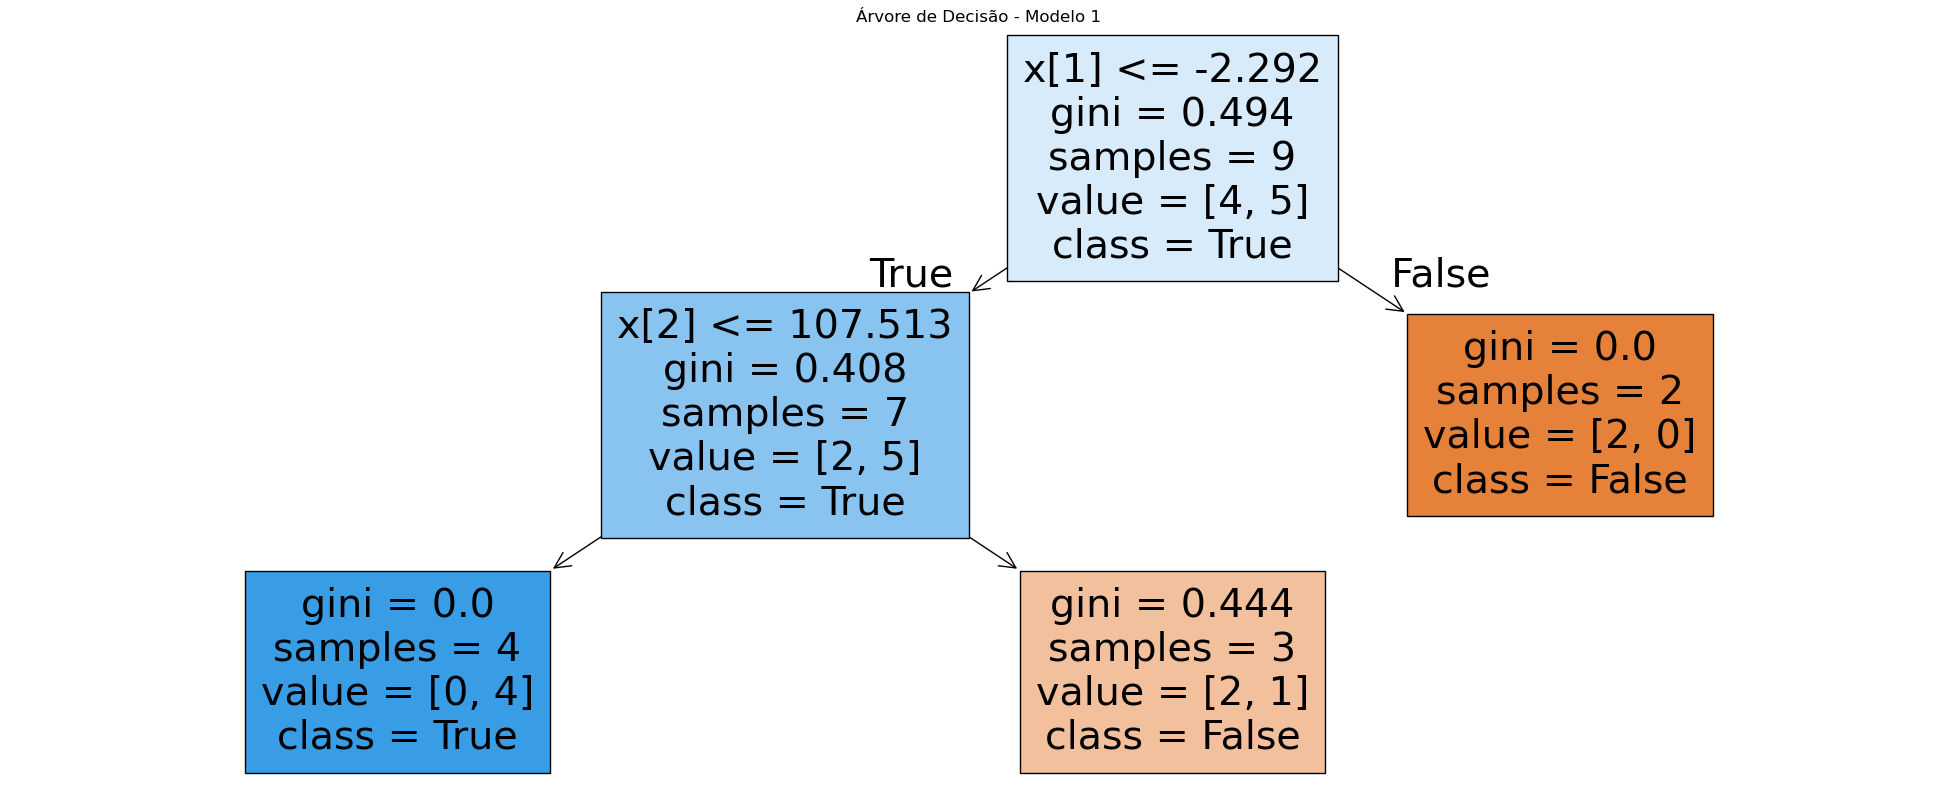

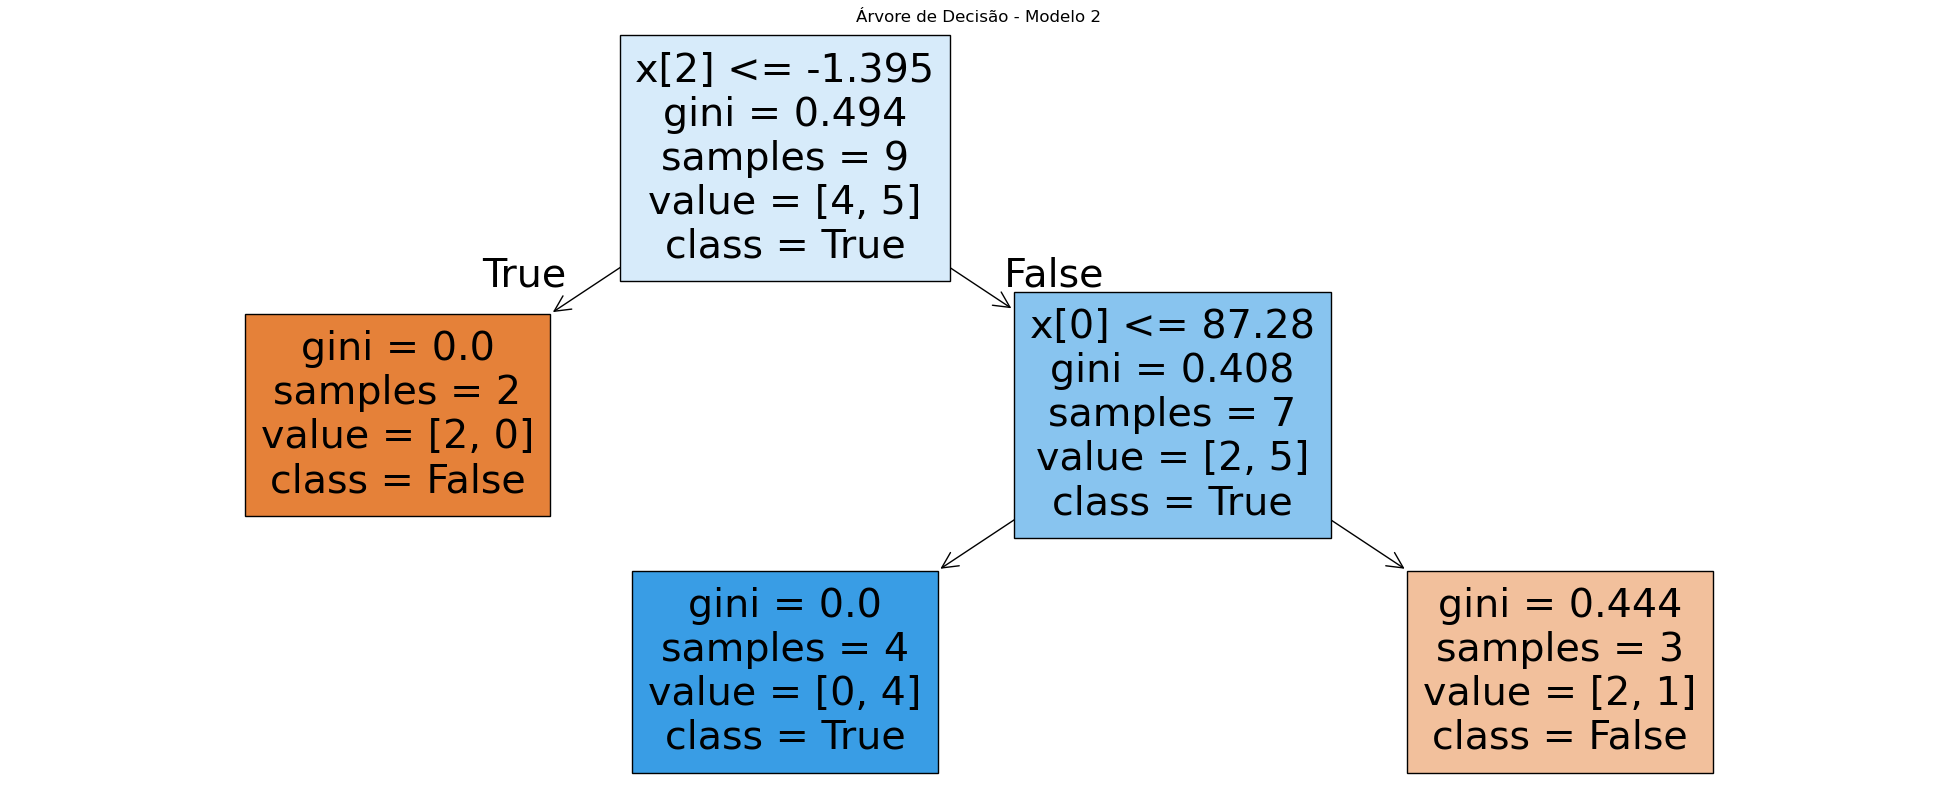

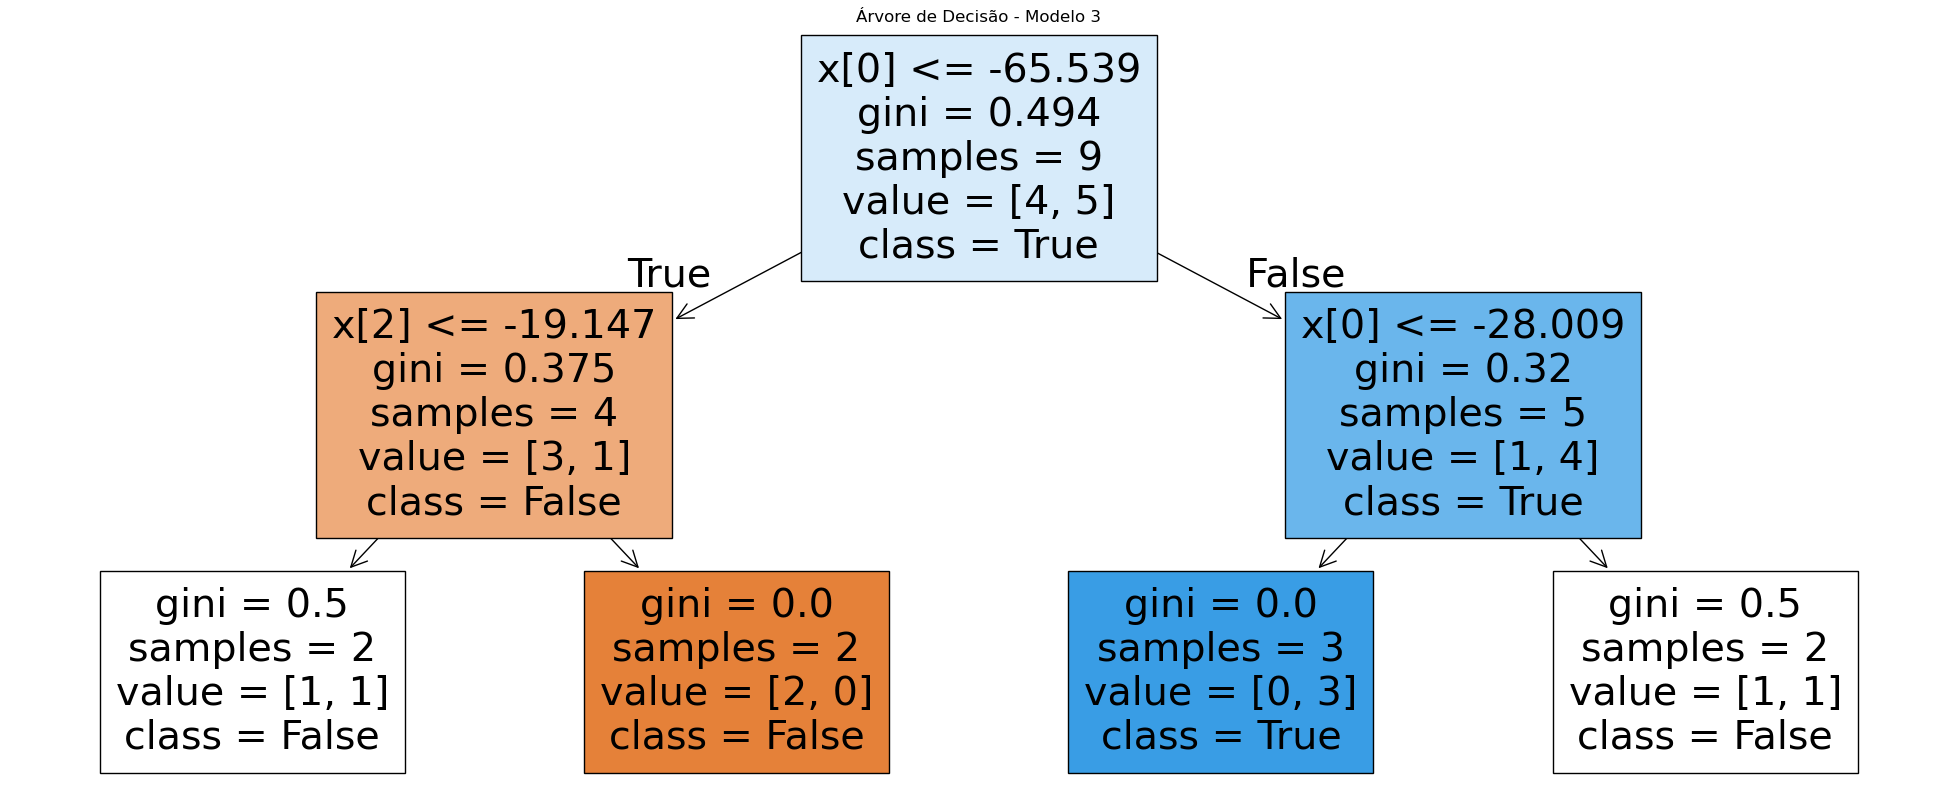

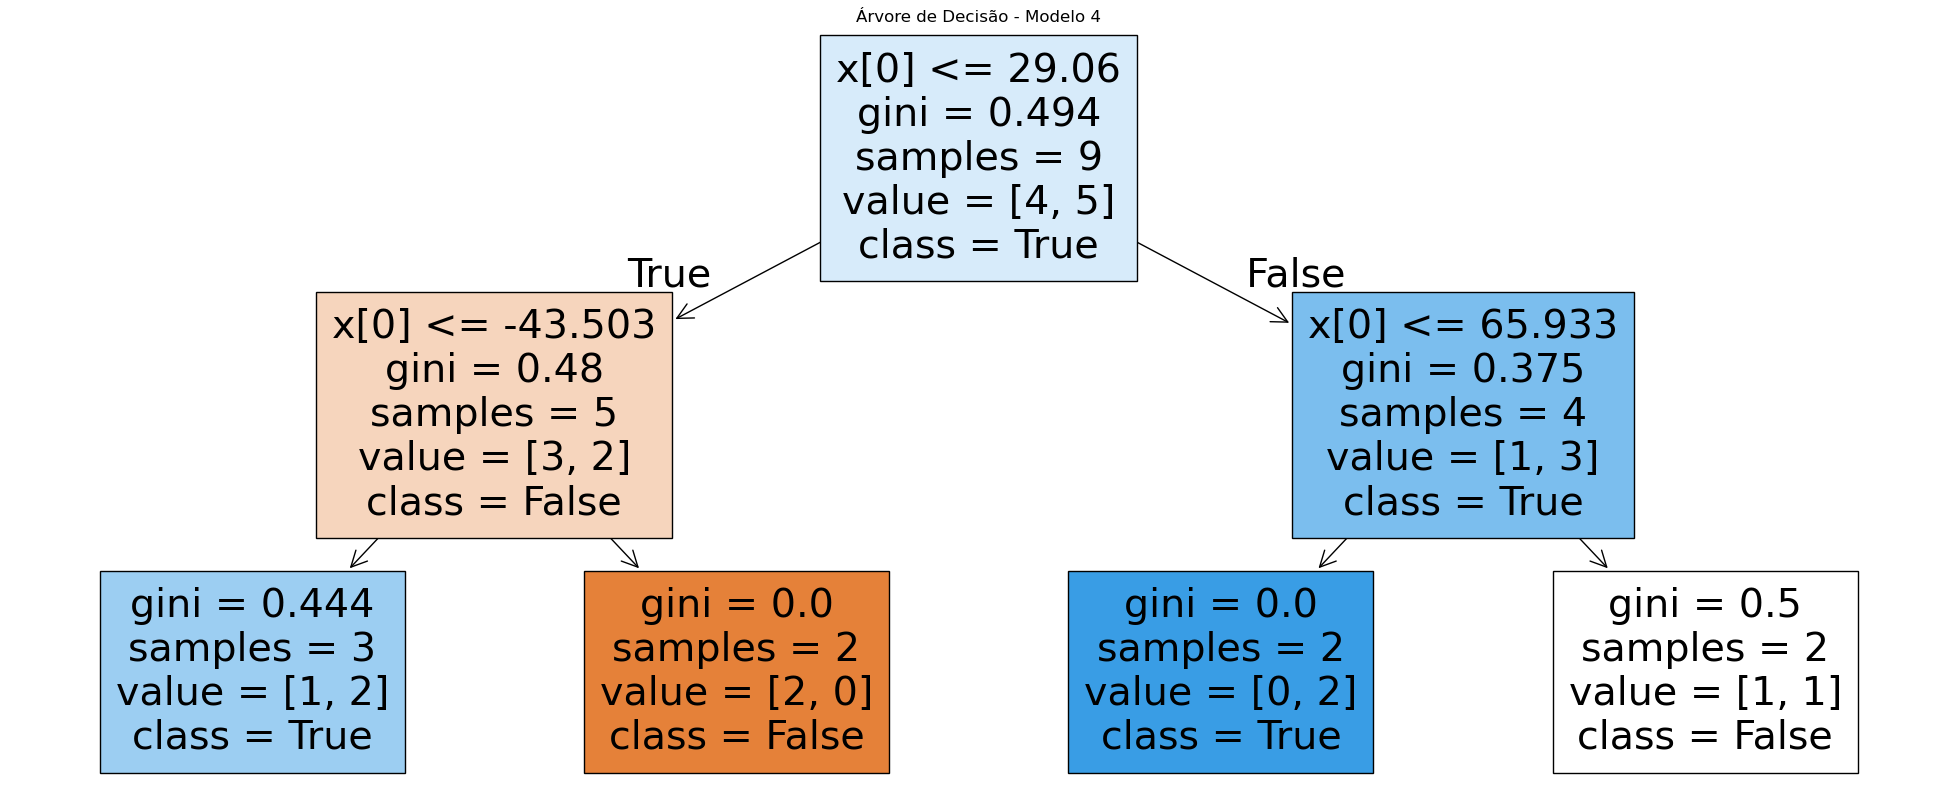

Previsões finais (votação da maioria): [0 0 0 0 0 0 0 0 0]


In [7]:
# Importação das bibliotecas necessárias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree
from scipy.stats import mode

# Criação de um DataFrame com valores aleatórios e colunas nomeadas
df = pd.DataFrame(
    np.random.randn(9, 4) * 100,  # Gera uma matriz 9x4 de números aleatórios multiplicados por 100
    columns=["coluna1", "coluna2", "coluna3", "coluna4"],  # Nome das colunas
)



# Adiciona uma coluna 'Interesse' com valores booleanos aleatórios
df["Interesse"] = np.random.choice([True, False], size=(9,))

# Realiza amostragem com reposição para criar subconjuntos de dados
amostragem1 = df.sample(n=9, replace=True).sample(
    n=3, replace=True, random_state=100, axis=1
)
amostragem2 = df.sample(n=9, replace=True).sample(
    n=3, replace=True, random_state=101, axis=1
)
amostragem3 = df.sample(n=9, replace=True).sample(
    n=3, replace=True, random_state=102, axis=1
)
amostragem4 = df.sample(n=9, replace=True).sample(
    n=3, replace=True, random_state=103, axis=1
)

# Criando um novo conjunto de teste com dados aleatórios
teste1 = pd.DataFrame(
    np.random.randn(9, 3) * 100, columns=[amostragem1.columns[0], amostragem1.columns[1], amostragem1.columns[2]]
)

teste2 = pd.DataFrame(
    np.random.randn(9, 3) * 100, columns=[amostragem2.columns[0], amostragem2.columns[1], amostragem2.columns[2]]   
)

teste3 = pd.DataFrame(
    np.random.randn(9, 3) * 100, columns=[amostragem3.columns[0], amostragem3.columns[1], amostragem3.columns[2]]   
)

teste4 = pd.DataFrame(
    np.random.randn(9, 3) * 100, columns=[amostragem4.columns[0], amostragem4.columns[1], amostragem4.columns[2]]
)

# Separa as variáveis independentes (features) de cada amostragem
coluna_de_interesse = "Interesse"
x_amostragem1 = amostragem1.drop(columns=[coluna_de_interesse]) if coluna_de_interesse in amostragem1.columns else amostragem1 
x_amostragem2 = amostragem2.drop(columns=[coluna_de_interesse]) if coluna_de_interesse in amostragem2.columns else amostragem2
x_amostragem3 = amostragem3.drop(columns=[coluna_de_interesse]) if coluna_de_interesse in amostragem3.columns else amostragem3
x_amostragem4 = amostragem4.drop(columns=[coluna_de_interesse]) if coluna_de_interesse in amostragem4.columns else amostragem4

# Separa a variável dependente (target) de cada amostragem
y_amostragem1 = df[coluna_de_interesse]
y_amostragem2 = df[coluna_de_interesse]
y_amostragem3 = df[coluna_de_interesse]
y_amostragem4 = df[coluna_de_interesse]

# Criação de modelos de árvore de decisão para cada amostragem
clf1 = DecisionTreeClassifier(random_state=100, max_depth=2)
clf2 = DecisionTreeClassifier(random_state=101, max_depth=2)
clf3 = DecisionTreeClassifier(random_state=102, max_depth=2)
clf4 = DecisionTreeClassifier(random_state=103, max_depth=2)

# Treinamento dos modelos com os dados de cada amostragem
clf1 = clf1.fit(x_amostragem1, y_amostragem1)
clf2 = clf2.fit(x_amostragem2, y_amostragem2)
clf3 = clf3.fit(x_amostragem3, y_amostragem3)
clf4 = clf4.fit(x_amostragem4, y_amostragem4)

# Visualização da árvore de decisão do primeiro modelo
arvore1 = plt.figure(figsize=(25, 10))
plot_tree(
    clf1,
    filled=True,  # Preenche os nós com cores baseadas nas classes
    class_names=["False", "True"],  # Nomes das classes
)
plt.title("Árvore de Decisão - Modelo 1")
plt.show()

# Visualização da árvore de decisão do segundo modelo
arvore2 = plt.figure(figsize=(25, 10))
plot_tree(
    clf2,
    filled=True,
    class_names=["False", "True"],
)
plt.title("Árvore de Decisão - Modelo 2")
plt.show()

# Visualização da árvore de decisão do terceiro modelo
arvore3 = plt.figure(figsize=(25, 10))
plot_tree(
    clf3,
    filled=True,
    class_names=["False", "True"],
)
plt.title("Árvore de Decisão - Modelo 3")
plt.show()

# Visualização da árvore de decisão do quarto modelo
arvore4 = plt.figure(figsize=(25, 10))
plot_tree(
    clf4,
    filled=True,
    class_names=["False", "True"],
)
plt.title("Árvore de Decisão - Modelo 4")
plt.show()

# Previsões dos modelos para o conjunto de teste
pred1 = clf1.predict(teste1)
pred2 = clf2.predict(teste2)
pred3 = clf3.predict(teste3)
pred4 = clf4.predict(teste4)

# Converte de booleano para inteiro
pred1 = pred1.astype(int)
pred2 = pred2.astype(int)
pred3 = pred3.astype(int)
pred4 = pred4.astype(int)

# Empilha as previsões (linhas: modelos, colunas: amostras)
todas_predicoes = np.vstack([pred1, pred2, pred3, pred4])

# Aplica a votação por maioria (ao longo das linhas)
predicao_final, _ = mode(todas_predicoes, axis=0, keepdims=False)

# Exibe as previsões finais
print("Previsões finais (votação da maioria):", predicao_final)
